umbralizacion con isodata


<function matplotlib.pyplot.show(close=None, block=None)>

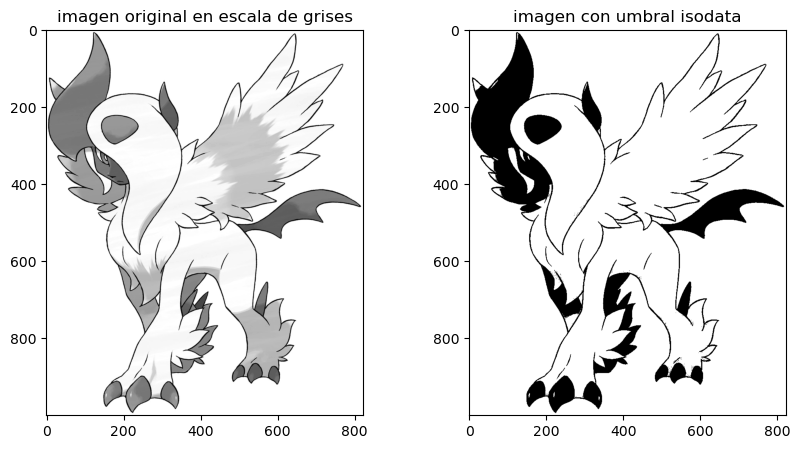

In [4]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

def isodata(imagen):
    umbral = 128
    while True:
        grupo1 = imagen[imagen<=umbral]
        grupo2 = imagen[imagen>=umbral]

        media1 = np.mean(grupo1)
        media2 = np.mean(grupo2)

        umbral_nuevo = (media1 + media2)/2

        if abs(umbral_nuevo-umbral) < 0.5:
            break

        umbral = umbral_nuevo
    return umbral

imagen = cv2.imread('absol1.jpg',0)

umbral_isodata = isodata(imagen)

_,imagen_isodata = cv2.threshold(imagen,umbral_isodata,255,cv2.THRESH_BINARY)

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.title('imagen original en escala de grises')
plt.imshow(imagen, cmap = 'gray')
plt.subplot(1,2,2)
plt.title('imagen con umbral isodata')
plt.imshow(imagen_isodata, cmap = 'gray')
plt.show

tecnica de dos picos 

<function matplotlib.pyplot.show(close=None, block=None)>

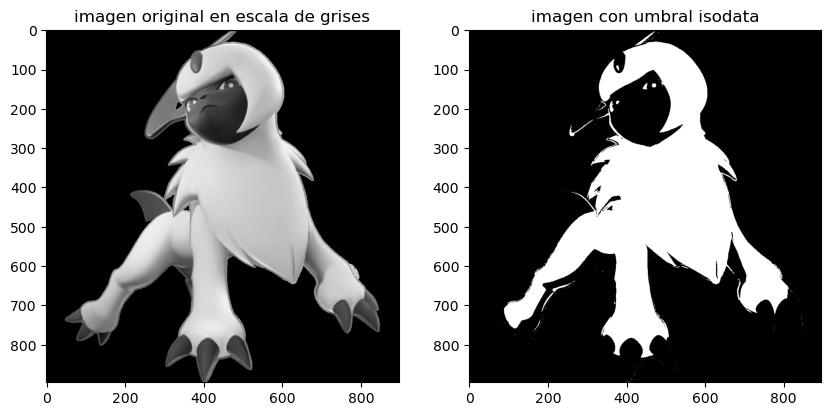

In [10]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

def dos_picos(imagen):
    hist = cv2.calcHist([imagen],[0],None,[256],[0,256])
    pico = np.array(hist)
    pico = pico.flatten()
    pico_dif = np.diff(pico)
    primer_pico = np.argmax(pico_dif[:128])
    segundo_pico = np.argmax(pico_dif[128:])+128
    umbral_2picos = int((primer_pico+segundo_pico)/2)
    return umbral_2picos

imagen = cv2.imread('absol2.png',0)
umbral_2pic = dos_picos(imagen)

_,imagen_2picos = cv2.threshold(imagen,umbral_2pic,255,cv2.THRESH_BINARY)

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.title('imagen original en escala de grises')
plt.imshow(imagen, cmap = 'gray')
plt.subplot(1,2,2)
plt.title('imagen con umbral isodata')
plt.imshow(imagen_2picos, cmap = 'gray')
plt.show

metodo de otsu

<function matplotlib.pyplot.show(close=None, block=None)>

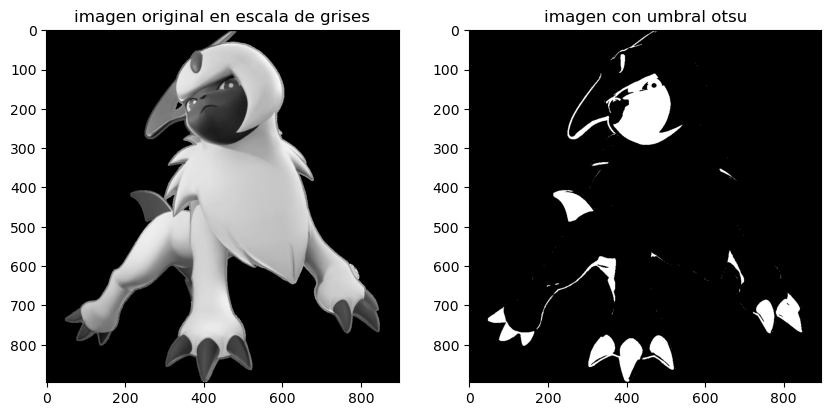

In [11]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

imagen = cv2.imread('absol2.png',0)
_,imagen_otsu = cv2.threshold(imagen,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

umbral_imagen = np.where(imagen>imagen_otsu,255,0).astype(np.uint8)

plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.title('imagen original en escala de grises')
plt.imshow(imagen, cmap = 'gray')
plt.subplot(1,2,2)
plt.title('imagen con umbral otsu')
plt.imshow(umbral_imagen, cmap = 'gray')
plt.show



umbralizacion variable - particion de una imagen

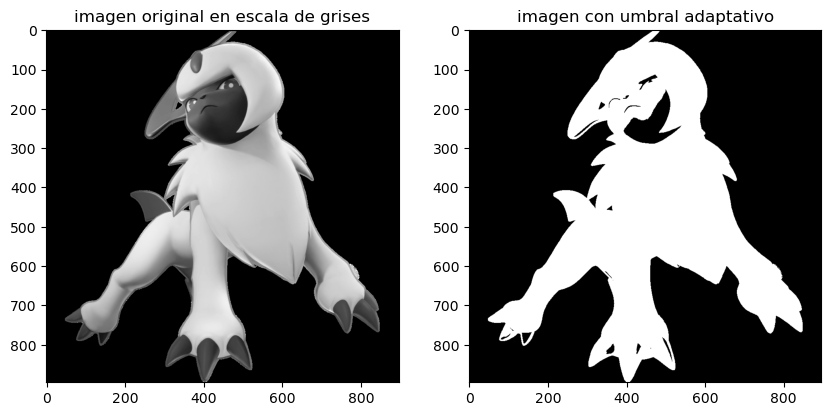

In [21]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

def variable_umb_block(image,tam_bloq,c):
    umbral_ima = np.zeros_like(image)
    for y in range(0,image.shape[0],tam_bloq):
        for x in range(0,image.shape[1],tam_bloq):
            bloque = image[y:y+tam_bloq,x:x+tam_bloq]
            bloque_media = np.mean(bloque)
            umbral_adap = bloque_media-c
            umbral_ima[y : y + tam_bloq, x : x + tam_bloq]=(bloque > umbral_adap)*255 
        return umbral_ima
    
image = cv2.imread('absol2.png',0)
tam_bloq = 1000
c = 10

umbral_imd_adap = variable_umb_block(image,tam_bloq,c)      
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.title('imagen original en escala de grises')
plt.imshow(image, cmap = 'gray')
plt.subplot(1,2,2)
plt.title('imagen con umbral adaptativo')
plt.imshow(umbral_imd_adap, cmap = 'gray')
plt.show()


UMBRAL Y ESO Dd

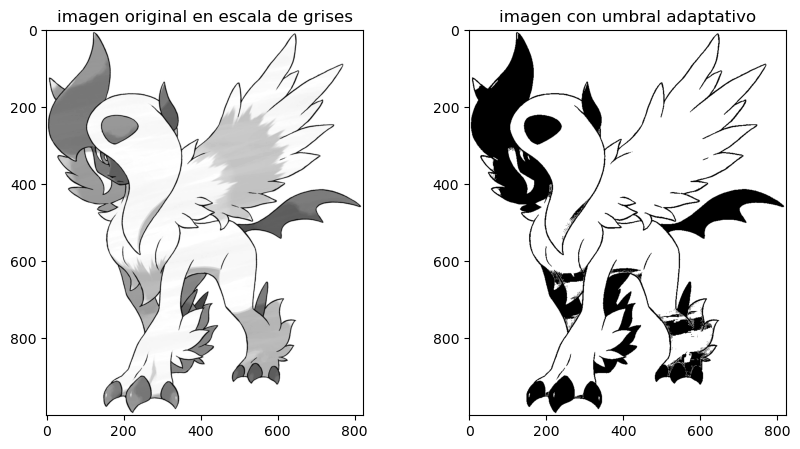

In [30]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

def umbra_var2 (image, tam_bloq, ajuste):
    umbral_ima = np.zeros_like(image)
    for y in range(0,image.shape[0],tam_bloq):
        for x in range(0,image.shape[1],tam_bloq):
            bloque = image[y:y+tam_bloq,x:x+tam_bloq]
            bloque_media = np.mean(bloque)
            des = np.std(bloque)
            umbral_adap = bloque_media-(ajuste*des)
            umbral_ima[y : y + tam_bloq, x : x + tam_bloq]=(bloque > umbral_adap)*255 
        return umbral_ima

image = cv2.imread('absol1.jpg',0)
tam_bloq = 1000
c = 0.8

umbral_ = umbra_var2(image,tam_bloq,c)      
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.title('imagen original en escala de grises')
plt.imshow(image, cmap = 'gray')
plt.subplot(1,2,2)
plt.title('imagen con umbral adaptativo')
plt.imshow(umbral_, cmap = 'gray')
plt.show()

ADAPTATIVO CON VENTANA

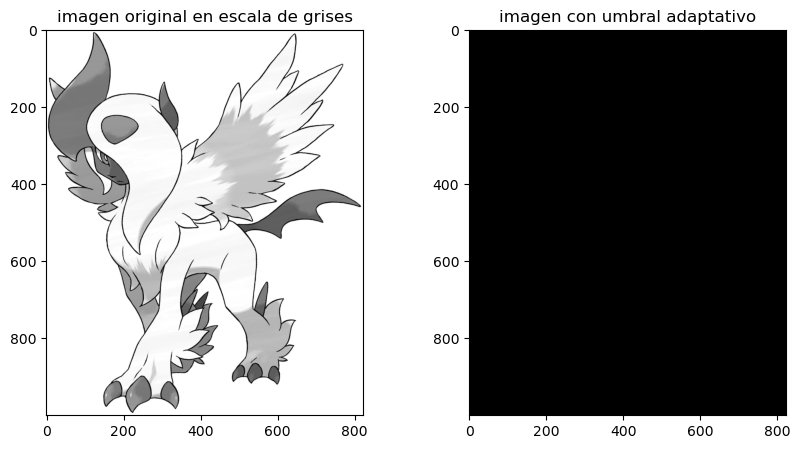

In [46]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

def ventana (imagen, ventana, factor):
    umbre_image = np.zeros_like(imagen)
    pad = ventana // 2
    padd_imge = cv2.copyMakeBorder(imagen,pad,pad,pad,pad,cv2.BORDER_REPLICATE)
    for y in range (imagen.shape[0]):
        for x in range (imagen.shape[1]):
            ventana1 = padd_imge[y:y+ventana,x:x+ventana]
            media = np.mean(ventana1)
            dis = np.std(ventana1)
            umbral = media -(factor*dis)
            umbre_image[y,x]=255 if imagen[y,x]>umbral else 0
        return umbre_image
    
image = cv2.imread('absol1.jpg',0)
tam_bloq = 31
c = 10

umbral_ = ventana(image,tam_bloq,c)      
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.title('imagen original en escala de grises')
plt.imshow(image, cmap = 'gray')
plt.subplot(1,2,2)
plt.title('imagen con umbral adaptativo')
plt.imshow(umbral_, cmap = 'gray')
plt.show()

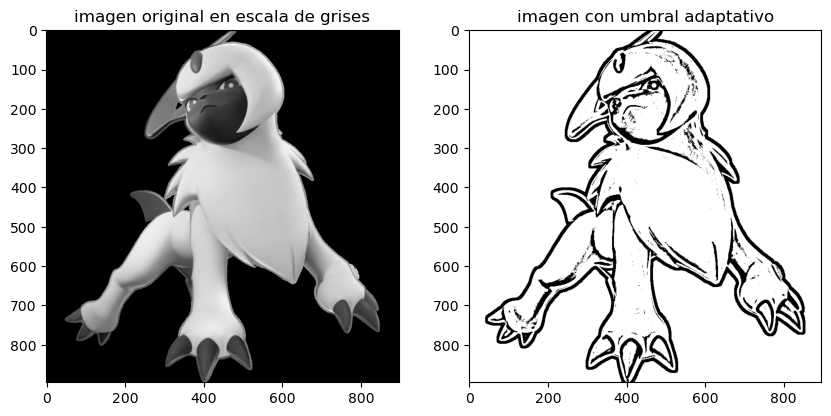

In [44]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

image = cv2.imread('absol2.png',0)
ventana = 15
factor = 2
imagen_umbr = cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,ventana,factor)
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.title('imagen original en escala de grises')
plt.imshow(image, cmap = 'gray')
plt.subplot(1,2,2)
plt.title('imagen con umbral adaptativo')
plt.imshow(imagen_umbr, cmap = 'gray')
plt.show()

METODO OTSU CON FUNCION Y FORMULA

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def otsu_threshold(image):
    hist, _ = np.histogram(image, bins=256, range=(0, 256))
    total = image.size
    sum_total = np.dot(np.arange(256), hist)
    
    sum_b, max_var, threshold = 0, 0, 0
    tam_b = 0
    
    for t in range(256):
        tam_b += hist[t]
        if tam_b == 0 or tam_b == total:
            continue
        
        sum_b += t * hist[t]
        mean_b, mean_f = sum_b / tam_b, (sum_total - sum_b) / (total - tam_b)
        var = tam_b * (mean_b - mean_f) ** 2
        
        if var > max_var:
            max_var, threshold = var, t

    return threshold, (image > threshold).astype(np.uint8) * 255

image = cv2.imread('absol2.png', 0)
umbral, umbral_imd_adap = otsu_threshold(image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen original en escala de grises')
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title(f'Imagen con umbral de Otsu (T={umbral})')
plt.imshow(umbral_imd_adap, cmap='gray')
plt.show()
